In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
# Cell 0: Extract Nested Zip Files from Kaggle Dataset
import zipfile
import os
from pathlib import Path
import shutil

print("📦 Extracting Brain Tumor Dataset")
print("=" * 70)

# Kaggle input directory (where you uploaded the dataset)
input_dir = Path('/kaggle/input')
working_dir = Path('/kaggle/working')
output_dir = working_dir / 'brain_tumor_data'
output_dir.mkdir(exist_ok=True)

print(f"📂 Input directory: {input_dir}")
print(f"📂 Output directory: {output_dir}")

# Find the dataset directory
dataset_dirs = [d for d in input_dir.iterdir() if d.is_dir()]
print(f"\n📁 Available datasets in /kaggle/input:")
for d in dataset_dirs:
    print(f"  - {d.name}")

# Locate your uploaded dataset
# Adjust the name if you used a different name when uploading
dataset_name = None
for d in dataset_dirs:
    if 'brain' in d.name.lower() or 'tumor' in d.name.lower():
        dataset_name = d.name
        break

if dataset_name is None:
    print("\n⚠️  Could not auto-detect dataset. Available datasets:")
    for d in dataset_dirs:
        print(f"  - {d.name}")
    print("\n❌ Please specify your dataset name manually")
else:
    dataset_path = input_dir / dataset_name
    print(f"\n✅ Found dataset: {dataset_name}")
    print(f"   Path: {dataset_path}")
    
    # List contents
    print(f"\n📋 Contents:")
    contents = list(dataset_path.iterdir())
    for item in contents:
        size = item.stat().st_size / (1024**2) if item.is_file() else 0
        print(f"  - {item.name} {'(dir)' if item.is_dir() else f'({size:.1f} MB)'}")
    
    # Extract nested zip files
    print("\n" + "=" * 70)
    print("📂 Extracting files...")
    print("=" * 70)
    
    zip_files = list(dataset_path.glob('*.zip'))
    
    if len(zip_files) == 0:
        print("⚠️  No zip files found. Checking for .mat files in subdirectories...")
        
        # Check subdirectories
        subdirs = [d for d in dataset_path.iterdir() if d.is_dir()]
        
        if subdirs:
            print(f"Found {len(subdirs)} subdirectories")
            total_mat_files = 0
            
            for subdir in subdirs:
                mat_files = list(subdir.glob('*.mat'))
                if mat_files:
                    print(f"\n  {subdir.name}: {len(mat_files)} .mat files")
                    # Copy all .mat files
                    for mat_file in mat_files:
                        shutil.copy(mat_file, output_dir / mat_file.name)
                    total_mat_files += len(mat_files)
            
            # Also copy root-level .mat files (like cvind.mat)
            root_mat_files = list(dataset_path.glob('*.mat'))
            for mat_file in root_mat_files:
                shutil.copy(mat_file, output_dir / mat_file.name)
                total_mat_files += 1
            
            print(f"\n✅ Copied {total_mat_files} total .mat files to {output_dir}")
        else:
            print("❌ No subdirectories or .mat files found.")
    else:
        print(f"Found {len(zip_files)} zip files")
        
        total_extracted = 0
        
        for zip_file in zip_files:
            print(f"\n📦 Extracting: {zip_file.name}")
            
            try:
                with zipfile.ZipFile(zip_file, 'r') as zip_ref:
                    # Get list of files
                    file_list = zip_ref.namelist()
                    
                    # Check if there are nested zips
                    nested_zips = [f for f in file_list if f.endswith('.zip')]
                    mat_files = [f for f in file_list if f.endswith('.mat')]
                    
                    if nested_zips:
                        print(f"  Contains {len(nested_zips)} nested zip files")
                        # Extract to temp dir
                        temp_dir = working_dir / 'temp_extract'
                        temp_dir.mkdir(exist_ok=True)
                        zip_ref.extractall(temp_dir)
                        
                        # Extract nested zips
                        for nested_zip in nested_zips:
                            nested_zip_path = temp_dir / nested_zip
                            print(f"    Extracting nested: {nested_zip}")
                            
                            with zipfile.ZipFile(nested_zip_path, 'r') as nested_ref:
                                nested_ref.extractall(output_dir)
                                total_extracted += len([f for f in nested_ref.namelist() if f.endswith('.mat')])
                        
                        # Clean up temp
                        shutil.rmtree(temp_dir)
                    
                    elif mat_files:
                        print(f"  Contains {len(mat_files)} .mat files directly")
                        zip_ref.extractall(output_dir)
                        total_extracted += len(mat_files)
                    
                    else:
                        print(f"  Unknown content, extracting all...")
                        zip_ref.extractall(output_dir)
            
            except Exception as e:
                print(f"  ❌ Error: {e}")
        
        print(f"\n✅ Extraction complete!")
        print(f"   Total .mat files: {total_extracted}")

# Verify extraction
print("\n" + "=" * 70)
print("🔍 Verifying extraction...")
print("=" * 70)

mat_files = list(output_dir.glob('*.mat'))
print(f"\nFound {len(mat_files)} .mat files in {output_dir}")

if len(mat_files) > 0:
    # Show sample file names
    print(f"\nSample files:")
    for i, f in enumerate(sorted(mat_files)[:5]):
        print(f"  {i+1}. {f.name}")
    if len(mat_files) > 5:
        print(f"  ... and {len(mat_files) - 5} more")
    
    print("\n✅ Dataset ready for processing!")
else:
    print("\n❌ No .mat files found. Please check the extraction.")

print("\n" + "=" * 70)
print("🎯 Next: Extract masks and labels from .mat files")
print("=" * 70)


📦 Extracting Brain Tumor Dataset
📂 Input directory: /kaggle/input
📂 Output directory: /kaggle/working/brain_tumor_data

📁 Available datasets in /kaggle/input:
  - brain-ag

✅ Found dataset: brain-ag
   Path: /kaggle/input/brain-ag

📋 Contents:
  - brainTumorDataPublic_1-766 (dir)
  - brainTumorDataPublic_2299-3064 (dir)
  - brainTumorDataPublic_1533-2298 (dir)
  - brainTumorDataPublic_767-1532 (dir)
  - README 2024.txt (0.0 MB)
  - cvind.mat (0.0 MB)

📂 Extracting files...
⚠️  No zip files found. Checking for .mat files in subdirectories...
Found 4 subdirectories

  brainTumorDataPublic_1-766: 766 .mat files

  brainTumorDataPublic_2299-3064: 766 .mat files

  brainTumorDataPublic_1533-2298: 766 .mat files

  brainTumorDataPublic_767-1532: 766 .mat files

✅ Copied 3065 total .mat files to /kaggle/working/brain_tumor_data

🔍 Verifying extraction...

Found 3065 .mat files in /kaggle/working/brain_tumor_data

Sample files:
  1. 1.mat
  2. 10.mat
  3. 100.mat
  4. 1000.mat
  5. 1001.mat
  

🔍 Multi-Task Dataset Extraction
📂 Dataset directory: /kaggle/working/brain_tumor_data
🏷️  Classes: ['meningioma', 'glioma', 'pituitary']

📊 Scanning dataset files...
Found 3064 .mat files

📥 Extracting images, masks, and labels...
  Progress: 0/3064 files...
  Progress: 500/3064 files...
  Progress: 1000/3064 files...
  Progress: 1500/3064 files...
  Progress: 2000/3064 files...
  Progress: 2500/3064 files...
  Progress: 3000/3064 files...

✅ Extraction complete!

📊 DATASET SUMMARY

Total files: 3064
Files with valid masks: 3064 (100.0%)
Files without masks: 0 (0.0%)

Mask coverage statistics:
  Mean coverage: 1.69%
  Min coverage: 0.10%
  Max coverage: 9.71%

Class distribution:
tumor_type
glioma        1426
meningioma     708
pituitary      930
Name: count, dtype: int64

Masks per class:
  Meningioma: 708/708 (100.0%)
  Glioma: 1426/1426 (100.0%)
  Pituitary: 930/930 (100.0%)

💾 Saved dataset info: /kaggle/working/dataset_multitask.csv

🎨 Visualizing samples with masks...
✅ Saved vis

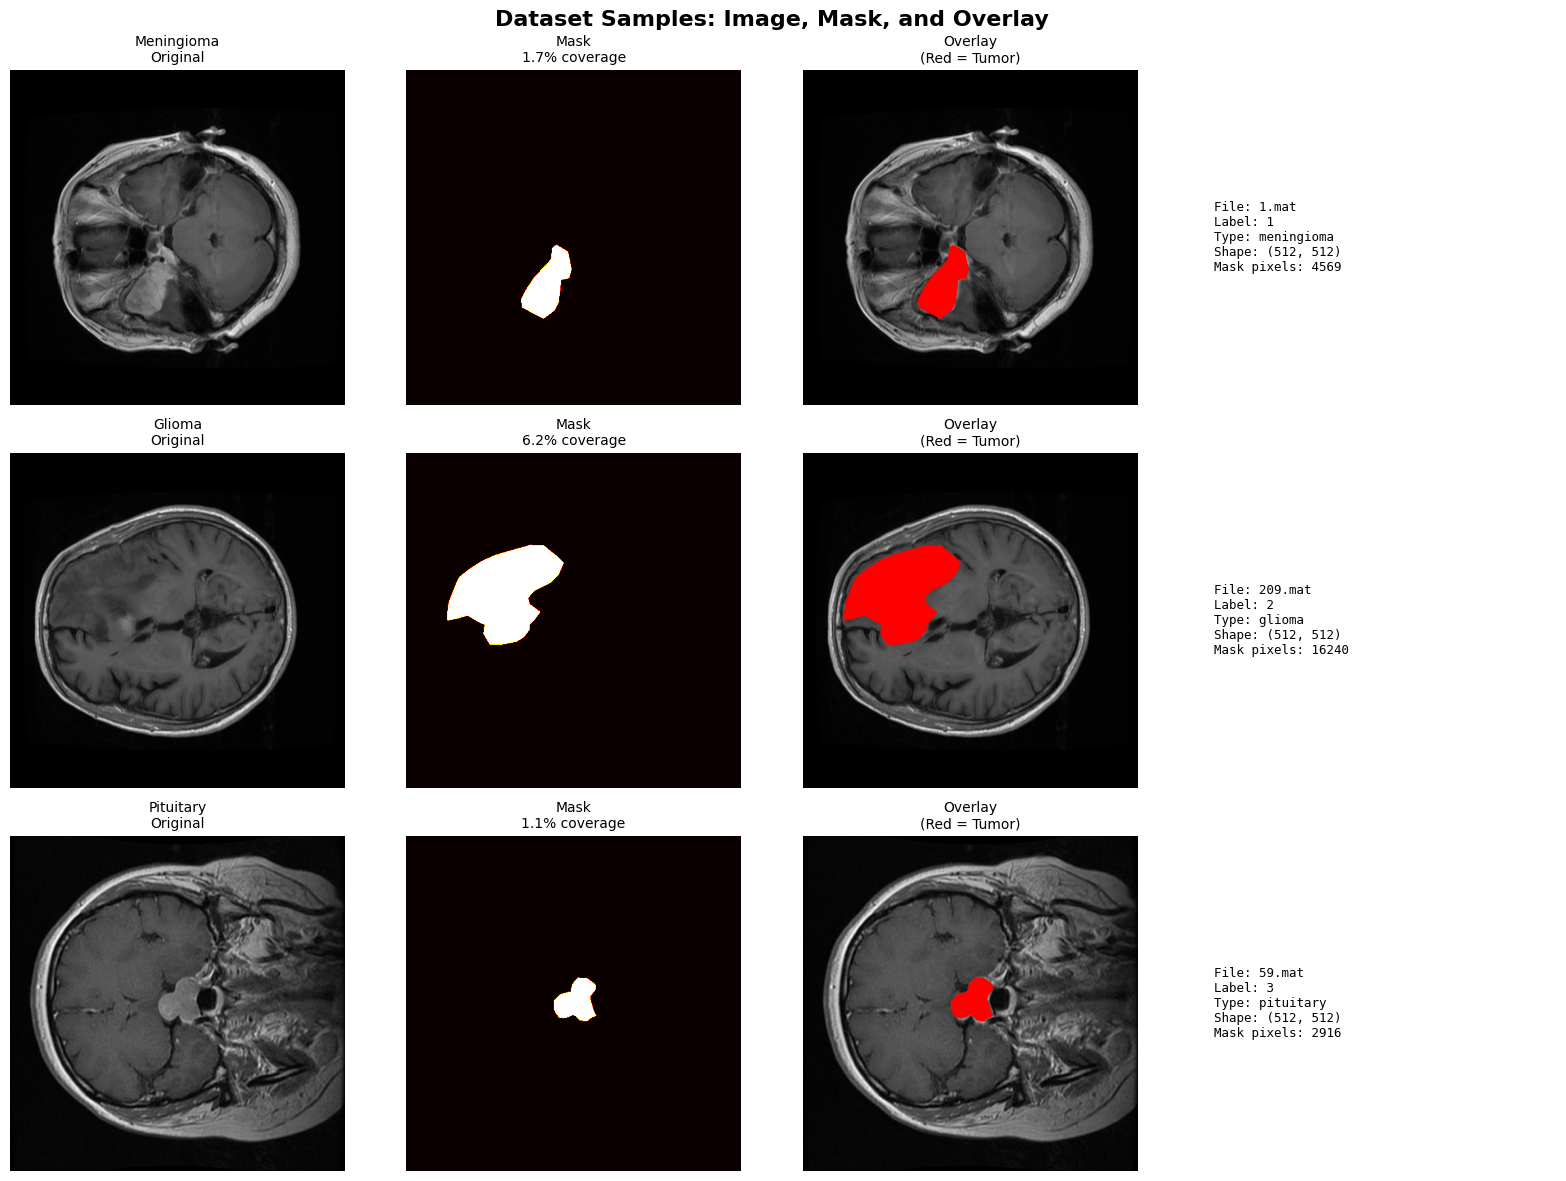


✅ Dataset extraction complete!

🎯 Next: Create train/val/test splits


In [3]:
# Cell 1: Extract Dataset with Masks and Labels
import h5py
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from collections import Counter

print("🔍 Multi-Task Dataset Extraction")
print("=" * 70)

# Setup paths
data_dir = Path('/kaggle/working/brain_tumor_data')

# Configuration
LABEL_MAP = {
    1: 'meningioma',
    2: 'glioma',
    3: 'pituitary'
}

print(f"📂 Dataset directory: {data_dir}")
print(f"🏷️  Classes: {list(LABEL_MAP.values())}")

# Function to load image, mask, and label from .mat file
def load_mat_data(file_path):
    """Load image, mask, and label from .mat file"""
    try:
        with h5py.File(file_path, 'r') as f:
            if 'cjdata' not in f:
                return None, None, None
            
            cjdata = f['cjdata']
            
            # Load image
            img = None
            if 'image' in cjdata:
                img_ref = cjdata['image']
                if isinstance(img_ref, h5py.Reference):
                    img = f[img_ref][:]
                else:
                    img = img_ref[:]
                
                # Transpose if needed
                if img.shape[0] < img.shape[1]:
                    img = img.T
            
            # Load mask
            mask = None
            if 'tumorMask' in cjdata:
                mask_ref = cjdata['tumorMask']
                if isinstance(mask_ref, h5py.Reference):
                    mask = f[mask_ref][:]
                else:
                    mask = mask_ref[:]
                
                # Transpose if needed
                if mask.ndim == 2 and mask.shape[0] < mask.shape[1]:
                    mask = mask.T
            
            # Load label
            label = None
            if 'label' in cjdata:
                label_ref = cjdata['label']
                if isinstance(label_ref, h5py.Reference):
                    label = int(f[label_ref][0, 0])
                else:
                    label = int(label_ref[0, 0])
            
            return img, mask, label
            
    except Exception as e:
        print(f"Error loading {file_path.name}: {e}")
        return None, None, None

# Get all .mat files
print("\n" + "=" * 70)
print("📊 Scanning dataset files...")
print("=" * 70)

mat_files = sorted([f for f in data_dir.glob('*.mat') if f.name != 'cvind.mat' and f.stem.isdigit()],
                   key=lambda x: int(x.stem))

print(f"Found {len(mat_files)} .mat files")

# Extract data from all files
print("\n" + "=" * 70)
print("📥 Extracting images, masks, and labels...")
print("=" * 70)

dataset_info = []
files_with_masks = 0
files_without_masks = 0
mask_coverage = []

for i, mat_file in enumerate(mat_files):
    if i % 500 == 0:
        print(f"  Progress: {i}/{len(mat_files)} files...")
    
    img, mask, label = load_mat_data(mat_file)
    
    if img is not None and label is not None:
        has_mask = mask is not None and mask.size > 0 and np.any(mask > 0)
        
        if has_mask:
            files_with_masks += 1
            # Calculate mask coverage (percentage of image with tumor)
            coverage = (np.count_nonzero(mask) / mask.size) * 100
            mask_coverage.append(coverage)
        else:
            files_without_masks += 1
        
        dataset_info.append({
            'file_number': int(mat_file.stem),
            'filename': mat_file.name,
            'label': label,
            'tumor_type': LABEL_MAP[label],
            'has_mask': has_mask,
            'image_shape': img.shape,
            'mask_coverage': coverage if has_mask else 0.0
        })

print(f"\n✅ Extraction complete!")

# Create DataFrame
df = pd.DataFrame(dataset_info)

# Summary statistics
print("\n" + "=" * 70)
print("📊 DATASET SUMMARY")
print("=" * 70)

print(f"\nTotal files: {len(df)}")
print(f"Files with valid masks: {files_with_masks} ({files_with_masks/len(df)*100:.1f}%)")
print(f"Files without masks: {files_without_masks} ({files_without_masks/len(df)*100:.1f}%)")

if mask_coverage:
    print(f"\nMask coverage statistics:")
    print(f"  Mean coverage: {np.mean(mask_coverage):.2f}%")
    print(f"  Min coverage: {np.min(mask_coverage):.2f}%")
    print(f"  Max coverage: {np.max(mask_coverage):.2f}%")

print(f"\nClass distribution:")
print(df['tumor_type'].value_counts().sort_index())

print(f"\nMasks per class:")
for tumor_type in ['meningioma', 'glioma', 'pituitary']:
    class_df = df[df['tumor_type'] == tumor_type]
    with_mask = class_df['has_mask'].sum()
    total = len(class_df)
    print(f"  {tumor_type.capitalize()}: {with_mask}/{total} ({with_mask/total*100:.1f}%)")

# Save dataset info
csv_path = Path('/kaggle/working/dataset_multitask.csv')
df.to_csv(csv_path, index=False)
print(f"\n💾 Saved dataset info: {csv_path}")

# Visualize samples with masks
print("\n" + "=" * 70)
print("🎨 Visualizing samples with masks...")
print("=" * 70)

# Get samples with masks from each class
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
fig.suptitle('Dataset Samples: Image, Mask, and Overlay', fontsize=16, fontweight='bold')

for class_idx, tumor_type in enumerate(['meningioma', 'glioma', 'pituitary']):
    # Get files with masks for this class
    class_df = df[(df['tumor_type'] == tumor_type) & (df['has_mask'] == True)]
    
    if len(class_df) == 0:
        print(f"⚠️  No masks found for {tumor_type}")
        continue
    
    # Pick first sample with mask
    sample = class_df.iloc[0]
    file_path = data_dir / sample['filename']
    
    # Load data
    img, mask, label = load_mat_data(file_path)
    
    # Normalize image
    img_norm = (img - img.min()) / (img.max() - img.min() + 1e-8)
    
    # Create overlay
    overlay = np.stack([img_norm]*3, axis=-1).copy()
    if mask is not None:
        mask_bool = mask > 0
        overlay[mask_bool] = [1, 0, 0]  # Red for tumor
    
    # Plot
    row = class_idx
    
    # Original image
    axes[row, 0].imshow(img_norm, cmap='gray')
    axes[row, 0].set_title(f'{tumor_type.capitalize()}\nOriginal', fontsize=10)
    axes[row, 0].axis('off')
    
    # Mask
    axes[row, 1].imshow(mask if mask is not None else np.zeros_like(img), cmap='hot')
    axes[row, 1].set_title(f'Mask\n{sample["mask_coverage"]:.1f}% coverage', fontsize=10)
    axes[row, 1].axis('off')
    
    # Overlay
    axes[row, 2].imshow(overlay)
    axes[row, 2].set_title('Overlay\n(Red = Tumor)', fontsize=10)
    axes[row, 2].axis('off')
    
    # Stats
    axes[row, 3].axis('off')
    stats_text = f"File: {sample['filename']}\n"
    stats_text += f"Label: {label}\n"
    stats_text += f"Type: {tumor_type}\n"
    stats_text += f"Shape: {img.shape}\n"
    stats_text += f"Mask pixels: {np.count_nonzero(mask) if mask is not None else 0}"
    axes[row, 3].text(0.1, 0.5, stats_text, fontsize=9, family='monospace',
                      verticalalignment='center')

plt.tight_layout()
plt.savefig('/kaggle/working/multitask_samples.png', dpi=150, bbox_inches='tight')
print("✅ Saved visualization: multitask_samples.png")
plt.show()

print("\n" + "=" * 70)
print("✅ Dataset extraction complete!")
print("\n🎯 Next: Create train/val/test splits")
print("=" * 70)


In [4]:
# Cell 2: Create Stratified Train/Val/Test Splits
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedShuffleSplit
from pathlib import Path

print("✂️ Creating Stratified Dataset Splits")
print("=" * 70)

# Load dataset info
csv_path = Path('/kaggle/working/dataset_multitask.csv')
if not csv_path.exists():
    raise FileNotFoundError(f"Dataset info not found at {csv_path}. Did you run Cell 1?")

df = pd.read_csv(csv_path)
print(f"Loaded {len(df)} records from {csv_path.name}")

# Function to perform stratified split
def create_splits(df, train_frac=0.7, val_frac=0.15, test_frac=0.15, random_state=42):
    # First split: Train vs Temp (Val + Test)
    split1 = StratifiedShuffleSplit(n_splits=1, test_size=(1 - train_frac), random_state=random_state)
    
    for train_idx, temp_idx in split1.split(df, df['tumor_type']):
        train_df = df.iloc[train_idx].copy()
        temp_df = df.iloc[temp_idx].copy()
    
    # Second split: Val vs Test
    # Calculate relative portion of val in temp
    val_rel_frac = val_frac / (val_frac + test_frac)
    
    split2 = StratifiedShuffleSplit(n_splits=1, test_size=(1 - val_rel_frac), random_state=random_state)
    
    for val_idx, test_idx in split2.split(temp_df, temp_df['tumor_type']):
        val_df = temp_df.iloc[val_idx].copy()
        test_df = temp_df.iloc[test_idx].copy()
        
    return train_df, val_df, test_df

# Execute split
print("\n🔄 Performing splits (70% Train, 15% Val, 15% Test)...")
train_df, val_df, test_df = create_splits(df)

# Add split label
train_df['split'] = 'train'
val_df['split'] = 'val'
test_df['split'] = 'test'

# Combine back
full_df = pd.concat([train_df, val_df, test_df])
full_df.to_csv('/kaggle/working/dataset_splits.csv', index=False)

# Save individual csvs
train_df.to_csv('/kaggle/working/train.csv', index=False)
val_df.to_csv('/kaggle/working/val.csv', index=False)
test_df.to_csv('/kaggle/working/test.csv', index=False)

print("\n📊 Split Statistics:")
print(f"  Train set: {len(train_df)} images ({len(train_df)/len(df)*100:.1f}%)")
print(f"  Val set:   {len(val_df)} images ({len(val_df)/len(df)*100:.1f}%)")
print(f"  Test set:  {len(test_df)} images ({len(test_df)/len(df)*100:.1f}%)")

print("\n⚖️ Class Balance Verification:")
print(f"{'Class':<12} {'Train':<8} {'Val':<8} {'Test':<8} {'Total':<8}")
print("-" * 50)

for tumor_type in sorted(df['tumor_type'].unique()):
    n_train = len(train_df[train_df['tumor_type'] == tumor_type])
    n_val = len(val_df[val_df['tumor_type'] == tumor_type])
    n_test = len(test_df[test_df['tumor_type'] == tumor_type])
    total = len(df[df['tumor_type'] == tumor_type])
    
    print(f"{tumor_type.capitalize():<12} {n_train:<8} {n_val:<8} {n_test:<8} {total:<8}")

print("\n" + "=" * 70)
print("✅ Splits created successfully!")
print("💾 Saved files: train.csv, val.csv, test.csv, dataset_splits.csv")
print("\n🎯 Next: Define Custom Dataset and Data Loaders")
print("=" * 70)



✂️ Creating Stratified Dataset Splits
Loaded 3064 records from dataset_multitask.csv

🔄 Performing splits (70% Train, 15% Val, 15% Test)...

📊 Split Statistics:
  Train set: 2144 images (70.0%)
  Val set:   460 images (15.0%)
  Test set:  460 images (15.0%)

⚖️ Class Balance Verification:
Class        Train    Val      Test     Total   
--------------------------------------------------
Glioma       998      214      214      1426    
Meningioma   495      106      107      708     
Pituitary    651      140      139      930     

✅ Splits created successfully!
💾 Saved files: train.csv, val.csv, test.csv, dataset_splits.csv

🎯 Next: Define Custom Dataset and Data Loaders


🏗️ Building Data Pipeline
⚙️ Configuration:
  Image Size: 256x256
  Batch Size: 16

🔄 Initializing Datasets and Loaders...
  Train Loader: 134 batches
  Val Loader:   29 batches
  Test Loader:  29 batches

🧪 Testing batch generation...


/usr/local/lib/python3.11/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/tmp/ipykernel_47/4016458136.py:101: UserWarning: Argument(s) 'alpha_affine' are not valid for transform ElasticTransform
  A.ElasticTransform(alpha=120, sigma=120 * 0.05, alpha_affine=120 * 0.03, p=0.5),
/tmp/ipykernel_47/4016458136.py:103: UserWarning: Argument(s) 'shift_limit' are not valid for transform OpticalDistortion
  A.OpticalDistortion(distort_limit=0.5, shift_limit=0.5, p=0.5),


  ✅ Batch loaded successfully!
  Images shape: torch.Size([16, 3, 256, 256])
  Masks shape:  torch.Size([16, 1, 256, 256])
  Labels shape: torch.Size([16])
  Labels: [2, 2, 2, 1, 0, 2, 0, 2, 1, 1, 1, 0, 1, 0, 1, 2]

🎨 Visualizing Augmented Batch (First 4 samples)


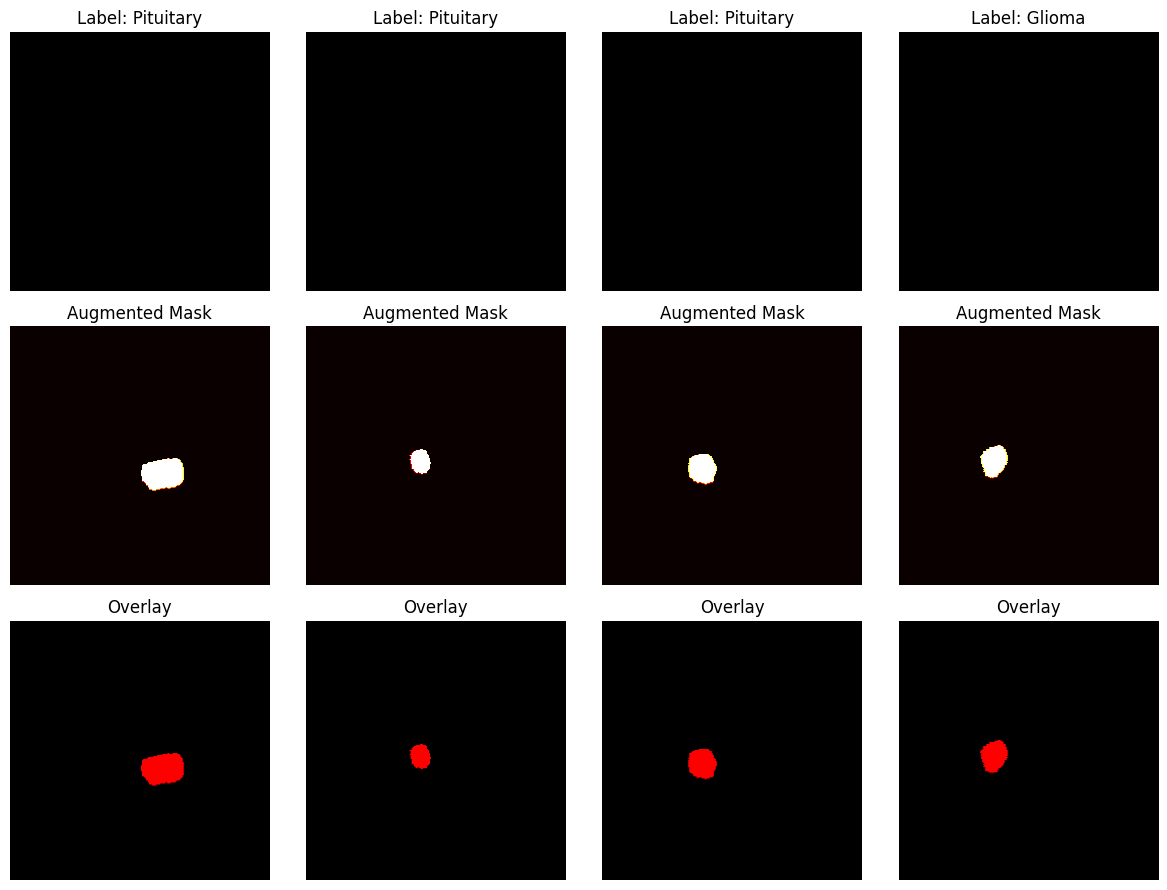

✅ Saved visualization: augmented_batch_sample.png

✅ Data Pipeline Ready!
🎯 Next: Define Multi-Task Model Architecture


In [5]:
# Cell 3: Data Loaders and Augmentation
import torch
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2
import cv2
import h5py
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

print("🏗️ Building Data Pipeline")
print("=" * 70)

# Configuration
IMG_SIZE = 256
BATCH_SIZE = 16  # Adjusted for Multi-Task model (try 8 if OOM occurs)
NUM_WORKERS = 2
PIN_MEMORY = True

print(f"⚙️ Configuration:")
print(f"  Image Size: {IMG_SIZE}x{IMG_SIZE}")
print(f"  Batch Size: {BATCH_SIZE}")

class BrainTumorDataset(Dataset):
    def __init__(self, df, data_dir, transform=None):
        self.df = df
        self.data_dir = Path(data_dir)
        self.transform = transform
        
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        file_path = self.data_dir / row['filename']
        label = int(row['label']) - 1  # Convert 1-3 to 0-2 for PyTorch CrossEntropy
        
        # Load data from .mat
        try:
            with h5py.File(file_path, 'r') as f:
                cjdata = f['cjdata']
                
                # Image
                img_ref = cjdata['image']
                if isinstance(img_ref, h5py.Reference):
                    image = f[img_ref][:]
                else:
                    image = img_ref[:]
                if image.ndim == 2 and image.shape[0] < image.shape[1]:
                    image = image.T
                
                # Mask
                mask_ref = cjdata['tumorMask']
                if isinstance(mask_ref, h5py.Reference):
                    mask = f[mask_ref][:]
                else:
                    mask = mask_ref[:]
                if mask.ndim == 2 and mask.shape[0] < mask.shape[1]:
                    mask = mask.T
                    
        except Exception as e:
            print(f"Error loading {file_path}: {e}")
            # Return dummy data in case of error (should not happen after verification)
            image = np.zeros((512, 512), dtype=np.float32)
            mask = np.zeros((512, 512), dtype=np.float32)

        # Normalize image to 0-1
        image = (image - image.min()) / (image.max() - image.min() + 1e-8)
        image = image.astype(np.float32)

        # Ensure mask is float32 for Albumentations and binary (0 or 1)
        mask = mask.astype(np.float32)
        mask[mask > 0] = 1.0
        
        # Convert to 3-channel image (EfficientNet expects RGB)
        image = np.stack([image]*3, axis=-1)
        
        # Apply transforms
        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented['image']
            mask = augmented['mask']
            
        # Ensure mask has channel dimension (1, H, W)
        if mask.ndim == 2:
            mask = mask.unsqueeze(0)
            
        return image, mask, torch.tensor(label, dtype=torch.long)

# Augmentation Pipelines
# NOTE: Albumentations handles mask transformation automatically if passed as 'mask'
train_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.2),
    A.Rotate(limit=30, p=0.5),
    A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.1, rotate_limit=0, p=0.3),
    A.OneOf([
        A.ElasticTransform(alpha=120, sigma=120 * 0.05, alpha_affine=120 * 0.03, p=0.5),
        A.GridDistortion(p=0.5),
        A.OpticalDistortion(distort_limit=0.5, shift_limit=0.5, p=0.5),
    ], p=0.3),
    A.OneOf([
        A.RandomBrightnessContrast(p=0.5),
        A.GaussNoise(p=0.3),
    ], p=0.3),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

val_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

print("\n🔄 Initializing Datasets and Loaders...")

# Load splits
data_dir = '/kaggle/working/brain_tumor_data'
train_df = pd.read_csv('/kaggle/working/train.csv')
val_df = pd.read_csv('/kaggle/working/val.csv')
test_df = pd.read_csv('/kaggle/working/test.csv')

# Create Datasets
train_dataset = BrainTumorDataset(train_df, data_dir, transform=train_transform)
val_dataset = BrainTumorDataset(val_df, data_dir, transform=val_transform)
test_dataset = BrainTumorDataset(test_df, data_dir, transform=val_transform)

# Create Loaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, 
                          num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, 
                        num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, 
                         num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)

print(f"  Train Loader: {len(train_loader)} batches")
print(f"  Val Loader:   {len(val_loader)} batches")
print(f"  Test Loader:  {len(test_loader)} batches")

# Test a batch
print("\n🧪 Testing batch generation...")
try:
    images, masks, labels = next(iter(train_loader))
    print(f"  ✅ Batch loaded successfully!")
    print(f"  Images shape: {images.shape}")
    print(f"  Masks shape:  {masks.shape}")
    print(f"  Labels shape: {labels.shape}")
    print(f"  Labels: {labels.tolist()}")
    
    # Visualization
    print("\n🎨 Visualizing Augmented Batch (First 4 samples)")
    fig, axes = plt.subplots(3, 4, figsize=(12, 9))
    
    # Denormalize for visualization
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    
    class_names = ['Meningioma', 'Glioma', 'Pituitary']
    
    for i in range(4):
        img_show = images[i] * std + mean
        img_show = img_show.permute(1, 2, 0).numpy()
        img_show = np.clip(img_show, 0, 1)
        
        mask_show = masks[i].squeeze().numpy()
        
        # Original Image
        axes[0, i].imshow(img_show)
        axes[0, i].set_title(f"Label: {class_names[labels[i]]}")
        axes[0, i].axis('off')
        
        # Mask
        axes[1, i].imshow(mask_show, cmap='hot')
        axes[1, i].set_title("Augmented Mask")
        axes[1, i].axis('off')
        
        # Overlay
        overlay = img_show.copy()
        overlay[mask_show > 0.5] = [1, 0, 0] # Red overlay
        axes[2, i].imshow(overlay)
        axes[2, i].set_title("Overlay")
        axes[2, i].axis('off')
        
    plt.tight_layout()
    plt.savefig('/kaggle/working/augmented_batch_sample.png')
    plt.show()
    print("✅ Saved visualization: augmented_batch_sample.png")

except Exception as e:
    print(f"❌ Error loading batch: {e}")
    import traceback
    traceback.print_exc()

print("\n" + "=" * 70)
print("✅ Data Pipeline Ready!")
print("🎯 Next: Define Multi-Task Model Architecture")
print("=" * 70)


🏗️ Building Data Pipeline
⚙️ Configuration:
  Image Size: 256x256
  Batch Size: 16

🔄 Initializing Datasets and Loaders...
  Train Loader: 134 batches
  Val Loader:   29 batches
  Test Loader:  29 batches

🧪 Testing batch generation...


/usr/local/lib/python3.11/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/tmp/ipykernel_47/2397227249.py:101: UserWarning: Argument(s) 'alpha_affine' are not valid for transform ElasticTransform
  A.ElasticTransform(alpha=120, sigma=120 * 0.05, alpha_affine=120 * 0.03, p=0.5),
/tmp/ipykernel_47/2397227249.py:103: UserWarning: Argument(s) 'shift_limit' are not valid for transform OpticalDistortion
  A.OpticalDistortion(distort_limit=0.5, shift_limit=0.5, p=0.5),


  ✅ Batch loaded successfully!
  Images shape: torch.Size([16, 3, 256, 256])
  Masks shape:  torch.Size([16, 1, 256, 256])
  Labels shape: torch.Size([16])
  Labels: [1, 2, 2, 1, 2, 1, 1, 2, 1, 1, 0, 1, 2, 0, 2, 0]

🎨 Visualizing Augmented Batch (First 4 samples)


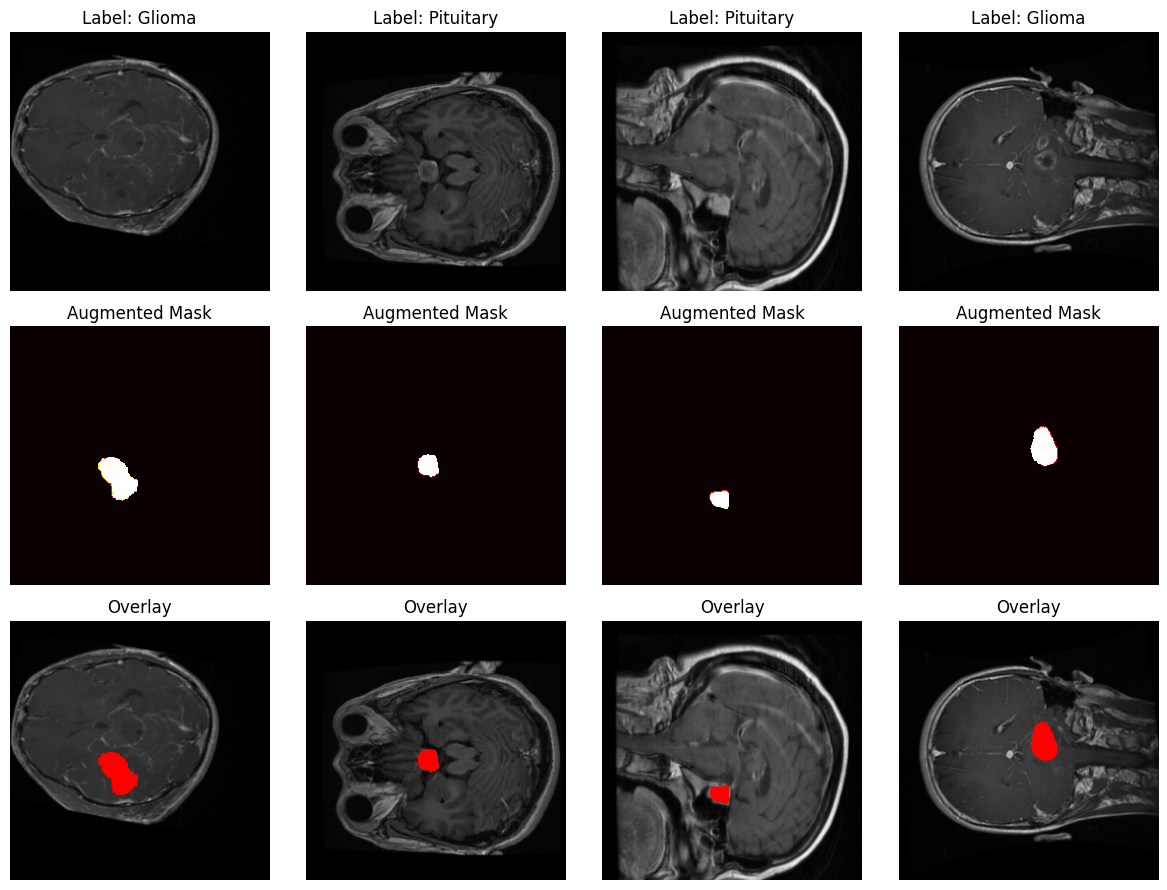

✅ Saved visualization: augmented_batch_sample.png

✅ Data Pipeline Ready!
🎯 Next: Define Multi-Task Model Architecture


In [11]:
# Cell 3: Data Loaders and Augmentation
import torch
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2
import cv2
import h5py
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

print("🏗️ Building Data Pipeline")
print("=" * 70)

# Configuration
IMG_SIZE = 256
BATCH_SIZE = 16  # Adjusted for Multi-Task model (try 8 if OOM occurs)
NUM_WORKERS = 2
PIN_MEMORY = True

print(f"⚙️ Configuration:")
print(f"  Image Size: {IMG_SIZE}x{IMG_SIZE}")
print(f"  Batch Size: {BATCH_SIZE}")

class BrainTumorDataset(Dataset):
    def __init__(self, df, data_dir, transform=None):
        self.df = df
        self.data_dir = Path(data_dir)
        self.transform = transform
        
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        file_path = self.data_dir / row['filename']
        label = int(row['label']) - 1  # Convert 1-3 to 0-2 for PyTorch CrossEntropy
        
        # Load data from .mat
        try:
            with h5py.File(file_path, 'r') as f:
                cjdata = f['cjdata']
                
                # Image
                img_ref = cjdata['image']
                if isinstance(img_ref, h5py.Reference):
                    image = f[img_ref][:]
                else:
                    image = img_ref[:]
                if image.ndim == 2 and image.shape[0] < image.shape[1]:
                    image = image.T
                
                # Mask
                mask_ref = cjdata['tumorMask']
                if isinstance(mask_ref, h5py.Reference):
                    mask = f[mask_ref][:]
                else:
                    mask = mask_ref[:]
                if mask.ndim == 2 and mask.shape[0] < mask.shape[1]:
                    mask = mask.T
                    
        except Exception as e:
            print(f"Error loading {file_path}: {e}")
            # Return dummy data in case of error (should not happen after verification)
            image = np.zeros((512, 512), dtype=np.float32)
            mask = np.zeros((512, 512), dtype=np.float32)

        # Normalize image to 0-1
        image = (image - image.min()) / (image.max() - image.min() + 1e-8)
        image = image.astype(np.float32)

        # Ensure mask is float32 for Albumentations and binary (0 or 1)
        mask = mask.astype(np.float32)
        mask[mask > 0] = 1.0
        
        # Convert to 3-channel image (EfficientNet expects RGB)
        image = np.stack([image]*3, axis=-1)
        
        # Apply transforms
        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented['image']
            mask = augmented['mask']
            
        # Ensure mask has channel dimension (1, H, W)
        if mask.ndim == 2:
            mask = mask.unsqueeze(0)
            
        return image, mask, torch.tensor(label, dtype=torch.long)

# Augmentation Pipelines
# NOTE: Albumentations handles mask transformation automatically if passed as 'mask'
train_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.2),
    A.Rotate(limit=30, p=0.5),
    A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.1, rotate_limit=0, p=0.3),
    A.OneOf([
        A.ElasticTransform(alpha=120, sigma=120 * 0.05, alpha_affine=120 * 0.03, p=0.5),
        A.GridDistortion(p=0.5),
        A.OpticalDistortion(distort_limit=0.5, shift_limit=0.5, p=0.5),
    ], p=0.3),
    A.OneOf([
        A.RandomBrightnessContrast(p=0.5),
        A.GaussNoise(p=0.3),
    ], p=0.3),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225), max_pixel_value=1.0),
    ToTensorV2()
])

val_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225), max_pixel_value=1.0),
    ToTensorV2()
])

print("\n🔄 Initializing Datasets and Loaders...")

# Load splits
data_dir = '/kaggle/working/brain_tumor_data'
train_df = pd.read_csv('/kaggle/working/train.csv')
val_df = pd.read_csv('/kaggle/working/val.csv')
test_df = pd.read_csv('/kaggle/working/test.csv')

# Create Datasets
train_dataset = BrainTumorDataset(train_df, data_dir, transform=train_transform)
val_dataset = BrainTumorDataset(val_df, data_dir, transform=val_transform)
test_dataset = BrainTumorDataset(test_df, data_dir, transform=val_transform)

# Create Loaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, 
                          num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, 
                        num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, 
                         num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)

print(f"  Train Loader: {len(train_loader)} batches")
print(f"  Val Loader:   {len(val_loader)} batches")
print(f"  Test Loader:  {len(test_loader)} batches")

# Test a batch
print("\n🧪 Testing batch generation...")
try:
    images, masks, labels = next(iter(train_loader))
    print(f"  ✅ Batch loaded successfully!")
    print(f"  Images shape: {images.shape}")
    print(f"  Masks shape:  {masks.shape}")
    print(f"  Labels shape: {labels.shape}")
    print(f"  Labels: {labels.tolist()}")
    
    # Visualization
    print("\n🎨 Visualizing Augmented Batch (First 4 samples)")
    fig, axes = plt.subplots(3, 4, figsize=(12, 9))
    
    # Denormalize for visualization
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    
    class_names = ['Meningioma', 'Glioma', 'Pituitary']
    
    for i in range(4):
        img_show = images[i] * std + mean
        img_show = img_show.permute(1, 2, 0).numpy()
        img_show = np.clip(img_show, 0, 1)
        
        mask_show = masks[i].squeeze().numpy()
        
        # Original Image
        axes[0, i].imshow(img_show)
        axes[0, i].set_title(f"Label: {class_names[labels[i]]}")
        axes[0, i].axis('off')
        
        # Mask
        axes[1, i].imshow(mask_show, cmap='hot')
        axes[1, i].set_title("Augmented Mask")
        axes[1, i].axis('off')
        
        # Overlay
        overlay = img_show.copy()
        overlay[mask_show > 0.5] = [1, 0, 0] # Red overlay
        axes[2, i].imshow(overlay)
        axes[2, i].set_title("Overlay")
        axes[2, i].axis('off')
        
    plt.tight_layout()
    plt.savefig('/kaggle/working/augmented_batch_sample.png')
    plt.show()
    print("✅ Saved visualization: augmented_batch_sample.png")

except Exception as e:
    print(f"❌ Error loading batch: {e}")
    import traceback
    traceback.print_exc()

print("\n" + "=" * 70)
print("✅ Data Pipeline Ready!")
print("🎯 Next: Define Multi-Task Model Architecture")
print("=" * 70)


In [12]:
# Cell 4: Multi-Task Model Architecture
import torch
import torch.nn as nn
import torch.nn.functional as F
import timm

print("🏗️ Building Multi-Task U-Net++ Model")
print("=" * 70)

class MultiTaskUNetPlusPlus(nn.Module):
    def __init__(self, encoder_name='tf_efficientnetv2_s', encoder_weights='imagenet', n_classes=3):
        super().__init__()
        
        print(f"  Initialized with backbone: {encoder_name}")
        
        # 1. Encoder (Backbone)
        self.encoder = timm.create_model(encoder_name, pretrained=True, features_only=True)
        
        # Get feature channel counts from encoder
        # Indices: 0: stride 2, 1: stride 4, 2: stride 8, 3: stride 16, 4: stride 32
        # For EfficientNetV2-S: [24, 48, 64, 160, 256] (can vary)
        dummy_input = torch.randn(1, 3, 256, 256)
        features = self.encoder(dummy_input)
        encoder_channels = [f.shape[1] for f in features]
        print(f"  Encoder channels: {encoder_channels}")
        
        # 2. Decoder (U-Net++ Style)
        # We'll use a simplified U-Net++ decoder logic manually for clarity
        dec_channels = [256, 128, 64, 32, 16]
        
        # Lateral connections (1x1 convs to adjust channels)
        self.conv1x1_4 = nn.Conv2d(encoder_channels[4], dec_channels[0], 1)
        self.conv1x1_3 = nn.Conv2d(encoder_channels[3], dec_channels[1], 1)
        self.conv1x1_2 = nn.Conv2d(encoder_channels[2], dec_channels[2], 1)
        self.conv1x1_1 = nn.Conv2d(encoder_channels[1], dec_channels[3], 1)
        self.conv1x1_0 = nn.Conv2d(encoder_channels[0], dec_channels[4], 1)
        
        # Upsampling blocks
        self.up4 = self._block(dec_channels[0] + dec_channels[1], dec_channels[1])
        self.up3 = self._block(dec_channels[1] + dec_channels[2], dec_channels[2])
        self.up2 = self._block(dec_channels[2] + dec_channels[3], dec_channels[3])
        self.up1 = self._block(dec_channels[3] + dec_channels[4], dec_channels[4])
        
        # Final upsampling block
        # Optimization: If u1 is already input resolution (stride 1) or stride 2, adjust here.
        # Based on previous run, it produced 512 output for 256 input, meaning u1 was 256.
        # So u1 is already full resolution. We just need Conv block.
        self.final_up = nn.Sequential(
            # nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True), # Removed extra upsample
            nn.Conv2d(dec_channels[4], 16, 3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True)
        )
        
        # 3. Segmentation Head (Outputs 1 channel mask)
        self.seg_head = nn.Conv2d(16, 1, kernel_size=1)
        
        # 4. Classification Head (Takes deepest features)
        self.global_pool = nn.AdaptiveAvgPool2d(1)
        self.cls_head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(encoder_channels[-1], 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(512, n_classes)
        )
        
    def _block(self, in_channels, out_channels):
        return nn.Sequential(
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True),
            nn.Conv2d(in_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
    
    def forward(self, x):
        # Encoder
        # features list: [e0, e1, e2, e3, e4] (strides 2, 4, 8, 16, 32)
        features = self.encoder(x)
        e0, e1, e2, e3, e4 = features
        
        # --- Classification Branch ---
        # Use deepest features (e4) for classification
        pooled = self.global_pool(e4)
        cls_out = self.cls_head(pooled)
        
        # --- Segmentation Branch (Decoder) ---
        # Adjust channels
        d4 = self.conv1x1_4(e4)
        d3 = self.conv1x1_3(e3)
        d2 = self.conv1x1_2(e2)
        d1 = self.conv1x1_1(e1)
        d0 = self.conv1x1_0(e0)
        
        # Upsample and concatenate (Skip connections)
        # Fix: Upsample d4 then concat with d3
        u4 = self.up4(torch.cat([F.interpolate(d4, size=d3.shape[2:], mode='bilinear', align_corners=True), d3], dim=1))
        # Upsample u4 then concat with d2
        u3 = self.up3(torch.cat([F.interpolate(u4, size=d2.shape[2:], mode='bilinear', align_corners=True), d2], dim=1))
        u2 = self.up2(torch.cat([F.interpolate(u3, size=d1.shape[2:], mode='bilinear', align_corners=True), d1], dim=1))
        u1 = self.up1(torch.cat([F.interpolate(u2, size=d0.shape[2:], mode='bilinear', align_corners=True), d0], dim=1))
        
        # Final upsample to original resolution (stride 2 -> stride 1)
        x = self.final_up(u1)
        
        # Segmentation output (Logits, no sigmoid yet)
        seg_out = self.seg_head(x)
        
        return seg_out, cls_out

# Create model instance
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\nUsing device: {device}")

model = MultiTaskUNetPlusPlus(n_classes=3).to(device)

print("\n✅ Model created successfully!")

# Test with dummy input
print("\n🧪 Testing Forward Pass...")
dummy_input = torch.randn(2, 3, 256, 256).to(device)
with torch.no_grad():
    seg_out, cls_out = model(dummy_input)

print(f"  Input shape: {dummy_input.shape}")
print(f"  Seg output:  {seg_out.shape} (Expected: [2, 1, 256, 256])")
print(f"  Cls output:  {cls_out.shape} (Expected: [2, 3])")

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\n📊 Model Statistics:")
print(f"  Total parameters: {total_params:,}")
print(f"  Trainable: {trainable_params:,}")

print("\n" + "=" * 70)
print("✅ Multi-Task Architecture Ready!")
print("🎯 Next: Define Custom Loss Functions and Training Loop")
print("=" * 70)


🏗️ Building Multi-Task U-Net++ Model

Using device: cuda
  Initialized with backbone: tf_efficientnetv2_s


Unexpected keys (bn2.bias, bn2.num_batches_tracked, bn2.running_mean, bn2.running_var, bn2.weight, classifier.bias, classifier.weight, conv_head.weight) found while loading pretrained weights. This may be expected if model is being adapted.


  Encoder channels: [24, 48, 64, 160, 256]

✅ Model created successfully!

🧪 Testing Forward Pass...
  Input shape: torch.Size([2, 3, 256, 256])
  Seg output:  torch.Size([2, 1, 256, 256]) (Expected: [2, 1, 256, 256])
  Cls output:  torch.Size([2, 3]) (Expected: [2, 3])

📊 Model Statistics:
  Total parameters: 20,861,092
  Trainable: 20,861,092

✅ Multi-Task Architecture Ready!
🎯 Next: Define Custom Loss Functions and Training Loop


⚙️ Defining Training Pipeline
🔧 Training Config:
  Epochs: 50
  Patience: 10
  Optimizer: AdamW (lr=1e-4)
  Loss Weights: Seg=1.0, Cls=0.5

🚀 STARTING TRAINING


/tmp/ipykernel_47/2527478875.py:62: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


Epoch 1/50 [Train]:   0%|          | 0/134 [00:00<?, ?it/s]

/tmp/ipykernel_47/2527478875.py:154: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_47/2527478875.py:202: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 1: Loss: 1.2585/0.9169 | Cls Acc: 77.29%/93.26% | HD: 84.2/56.1 | Time: 40s
  💾 Model Saved! (Best Val Loss: 0.9169)


...

Epoch 48: Loss: 0.2949/0.3158 | Cls Acc: 99.91%/99.13% | HD: 10.3/11.3 | Time: 39s
  ⏳ No improvement (3/10)


Epoch 49/50 [Train]:   0%|          | 0/134 [00:00<?, ?it/s]

Epoch 49: Loss: 0.2964/0.3162 | Cls Acc: 99.77%/99.35% | HD: 10.3/11.2 | Time: 39s
  ⏳ No improvement (4/10)


Epoch 50/50 [Train]:   0%|          | 0/134 [00:00<?, ?it/s]

Epoch 50: Loss: 0.3005/0.3150 | Cls Acc: 99.67%/99.13% | HD: 10.4/11.5 | Time: 39s
  ⏳ No improvement (5/10)

✅ Training Complete!
💾 Best model saved to: best_multitask_model.pth

📈 Plotting Training Curves...


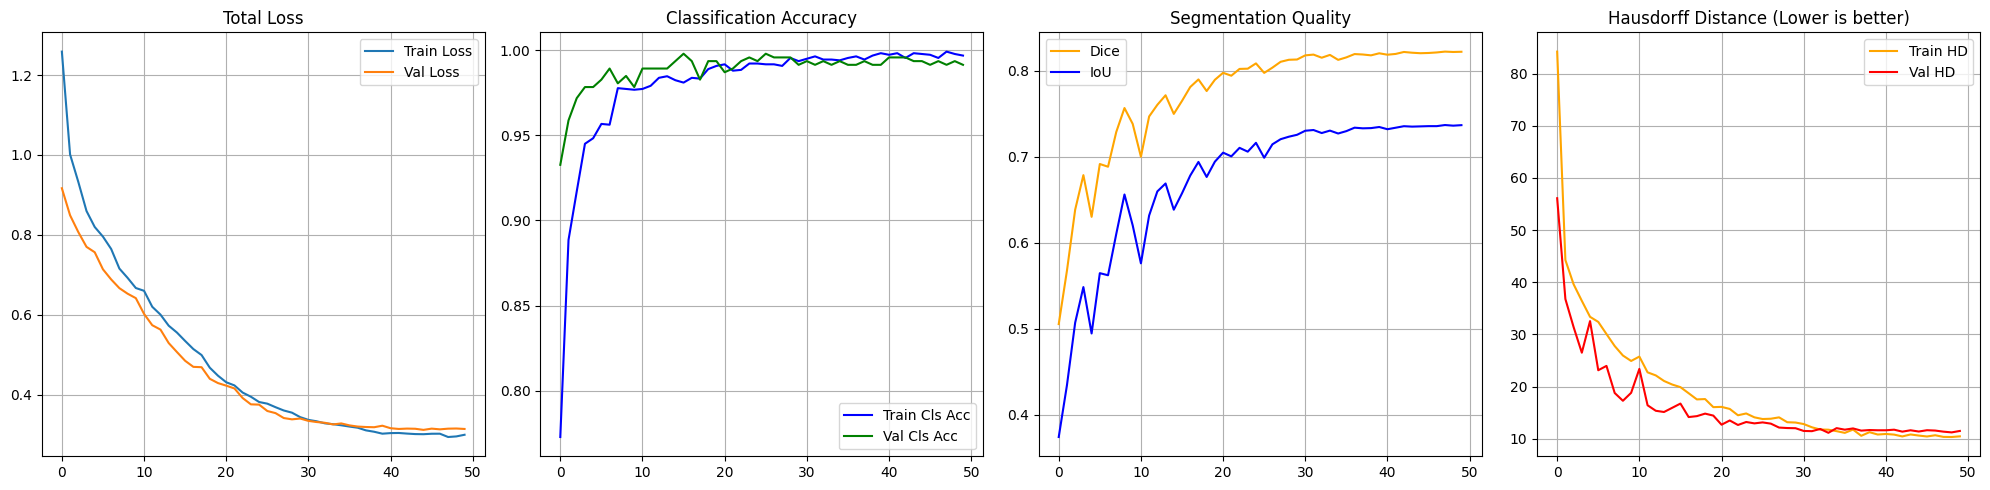

✅ Saved plot: training_curves.png


In [13]:
# Cell 5: Training Loop with Multi-Task Loss
import torch.optim as optim
from torch.cuda.amp import GradScaler, autocast
from torch.optim.lr_scheduler import CosineAnnealingLR
import time
import copy
from tqdm.notebook import tqdm

print("⚙️ Defining Training Pipeline")
print("=" * 70)

# --- 1. Loss Functions ---

class DiceLoss(nn.Module):
    def __init__(self, smooth=1.0):
        super().__init__()
        self.smooth = smooth
        
    def forward(self, pred, target):
        pred = torch.sigmoid(pred)
        
        # Flatten
        pred = pred.view(-1)
        target = target.view(-1)
        
        intersection = (pred * target).sum()
        dice = (2. * intersection + self.smooth) / (pred.sum() + target.sum() + self.smooth)
        
        return 1 - dice

class MultiTaskLoss(nn.Module):
    def __init__(self, seg_weight=1.0, cls_weight=1.0):
        super().__init__()
        self.seg_weight = seg_weight
        self.cls_weight = cls_weight
        
        # Segmentation: Dice + BCE
        self.dice = DiceLoss()
        self.bce = nn.BCEWithLogitsLoss()
        
        # Classification: CrossEntropy with Label Smoothing
        self.ce = nn.CrossEntropyLoss(label_smoothing=0.05)
        
    def forward(self, seg_pred, seg_target, cls_pred, cls_target):
        # Segmentation Loss
        dice_loss = self.dice(seg_pred, seg_target)
        bce_loss = self.bce(seg_pred, seg_target)
        seg_loss = 0.5 * dice_loss + 0.5 * bce_loss
        
        # Classification Loss
        cls_loss = self.ce(cls_pred, cls_target)
        
        # Total Loss
        total_loss = (self.seg_weight * seg_loss) + (self.cls_weight * cls_loss)
        
        return total_loss, seg_loss, cls_loss

# --- 2. Training Configuration ---

criterion = MultiTaskLoss(seg_weight=1.0, cls_weight=1.0) # Equal importance
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-2)
scaler = GradScaler()
scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

EPOCHS = 50
patience = 10
best_val_loss = float('inf')
early_stop_counter = 0

print(f"🔧 Training Config:")
print(f"  Epochs: {EPOCHS}")
print(f"  Patience: {patience}")
print(f"  Optimizer: AdamW (lr=1e-4)")
print(f"  Loss Weights: Seg=1.0, Cls=0.5")

# --- 3. Training Loop ---

history = {
    'train_loss': [], 'train_seg_loss': [], 'train_cls_loss': [],
    'train_cls_acc': [], 'train_seg_hd': [],
    'val_loss': [], 'val_seg_loss': [], 'val_cls_loss': [],
    'val_cls_acc': [], 'val_seg_dice': [], 'val_seg_iou': [],
    'val_seg_hd': [], 'val_seg_acc': []
}

from scipy.spatial.distance import directed_hausdorff

def calculate_metrics(pred, target, threshold=0.5):
    """Calculate Dice, IoU, Pixel Acc, and Hausdorff Distance"""
    pred_mask = (torch.sigmoid(pred) > threshold).float()
    
    # 1. Pixel Accuracy
    correct = (pred_mask == target).sum().item()
    total = torch.numel(pred_mask)
    pixel_acc = correct / (total + 1e-8)
    
    # 2. Dice & IoU
    intersection = (pred_mask * target).sum().item()
    union = pred_mask.sum().item() + target.sum().item()
    
    dice = (2.0 * intersection) / (union + 1e-8)
    iou = intersection / (union - intersection + 1e-8) # Jaccard
    
    # 3. Hausdorff Distance (using scipy)
    # Convert to numpy for scipy
    pred_np = pred_mask.squeeze().cpu().numpy()
    target_np = target.squeeze().cpu().numpy()
    
    # Only calculate HD if both have foreground pixels
    if np.any(pred_np) and np.any(target_np):
        # get coordinates of non-zero pixels
        pred_coords = np.argwhere(pred_np)
        target_coords = np.argwhere(target_np)
        
        d1 = directed_hausdorff(pred_coords, target_coords)[0]
        d2 = directed_hausdorff(target_coords, pred_coords)[0]
        hd = max(d1, d2)
    else:
        # If one is empty and other isn't, HD is "infinite" or max dist (e.g. diagonal)
        # If both empty, HD is 0
        if not np.any(pred_np) and not np.any(target_np):
            hd = 0.0
        else:
            hd = 100.0 # Arbitrary large value (penalty)
            
    return dice, iou, hd, pixel_acc

def calculate_accuracy(pred, target):
    _, predicted = torch.max(pred, 1)
    correct = (predicted == target).sum().item()
    return correct / target.size(0)

print("\n🚀 STARTING TRAINING")
print("=" * 70)

for epoch in range(EPOCHS):
    start_time = time.time()
    
    # --- TRAIN ---
    model.train()
    train_loss, train_seg_loss, train_cls_loss = 0, 0, 0
    train_correct = 0
    train_total = 0
    train_hd_sum = 0
    n_train_samples = 0
    
    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Train]", leave=False)
    
    for imgs, masks, labels in loop:
        imgs, masks, labels = imgs.to(device), masks.to(device), labels.to(device)
        
        optimizer.zero_grad()
        
        with autocast():
            seg_pred, cls_pred = model(imgs)
            loss, s_loss, c_loss = criterion(seg_pred, masks, cls_pred, labels)
        
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        # Accumulate metrics
        train_loss += loss.item()
        train_seg_loss += s_loss.item()
        train_cls_loss += c_loss.item()
        
        # Classification Acc
        train_correct += (cls_pred.argmax(1) == labels).sum().item()
        train_total += labels.size(0)
        
        # Hausdorff Distance (per sample)
        for i in range(len(imgs)):
            _, _, hd, _ = calculate_metrics(seg_pred[i], masks[i])
            train_hd_sum += hd
            n_train_samples += 1
        
        loop.set_postfix(loss=loss.item())
        
    train_loss /= len(train_loader)
    train_seg_loss /= len(train_loader)
    train_cls_loss /= len(train_loader)
    train_cls_acc = train_correct / train_total
    train_hd = train_hd_sum / n_train_samples
    
    # --- VALIDATION ---
    model.eval()
    val_loss, val_seg_loss, val_cls_loss = 0, 0, 0
    val_correct = 0
    val_total = 0
    
    # Validation Metrics Accumulators
    val_dice_sum = 0
    val_iou_sum = 0
    val_hd_sum = 0
    val_seg_acc_sum = 0
    n_val_samples = 0
    
    with torch.no_grad():
        for imgs, masks, labels in val_loader:
            imgs, masks, labels = imgs.to(device), masks.to(device), labels.to(device)
            
            with autocast():
                seg_pred, cls_pred = model(imgs)
                loss, s_loss, c_loss = criterion(seg_pred, masks, cls_pred, labels)
            
            val_loss += loss.item()
            val_seg_loss += s_loss.item()
            val_cls_loss += c_loss.item()
            
            # Classification Acc
            val_correct += (cls_pred.argmax(1) == labels).sum().item()
            val_total += labels.size(0)
            
            # Segmentation Metrics (per sample)
            for i in range(len(imgs)):
                d, iou, hd, acc = calculate_metrics(seg_pred[i], masks[i])
                val_dice_sum += d
                val_iou_sum += iou
                val_hd_sum += hd
                val_seg_acc_sum += acc
                n_val_samples += 1
                
    val_loss /= len(val_loader)
    val_seg_loss /= len(val_loader)
    val_cls_loss /= len(val_loader)
    val_cls_acc = val_correct / val_total
    
    # Average segmentation metrics
    val_dice = val_dice_sum / n_val_samples
    val_iou = val_iou_sum / n_val_samples
    val_hd = val_hd_sum / n_val_samples
    val_seg_acc = val_seg_acc_sum / n_val_samples
    
    # Update scheduler
    scheduler.step()
    
    # Logging
    duration = time.time() - start_time
    print(f"Epoch {epoch+1}: "
          f"Loss: {train_loss:.4f}/{val_loss:.4f} | "
          f"Cls Acc: {train_cls_acc:.2%}/{val_cls_acc:.2%} | "
          f"HD: {train_hd:.1f}/{val_hd:.1f} | "
          f"Time: {duration:.0f}s")
    
    # Store history
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_cls_acc'].append(train_cls_acc)
    history['val_cls_acc'].append(val_cls_acc)
    history['train_seg_hd'].append(train_hd)
    history['val_seg_dice'].append(val_dice)
    history['val_seg_iou'].append(val_iou)
    history['val_seg_hd'].append(val_hd)
    history['val_seg_acc'].append(val_seg_acc)
    
    # Checkpointing
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        early_stop_counter = 0
        torch.save(model.state_dict(), '/kaggle/working/best_multitask_model.pth')
        print(f"  💾 Model Saved! (Best Val Loss: {best_val_loss:.4f})")
    else:
        early_stop_counter += 1
        print(f"  ⏳ No improvement ({early_stop_counter}/{patience})")
        
    if early_stop_counter >= patience:
        print("\n🛑 Early stopping triggered!")
        break

print("\n" + "=" * 70)
print("✅ Training Complete!")
print("💾 Best model saved to: best_multitask_model.pth")

# Plot training curves
print("\n📈 Plotting Training Curves...")
plt.figure(figsize=(20, 5))

# Loss
plt.subplot(1, 4, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.title('Total Loss')
plt.legend()
plt.grid(True)

# Classification Accuracy
plt.subplot(1, 4, 2)
plt.plot(history['train_cls_acc'], color='blue', label='Train Cls Acc')
plt.plot(history['val_cls_acc'], color='green', label='Val Cls Acc')
plt.title('Classification Accuracy')
plt.legend()
plt.grid(True)

# Segmentation Metrics
plt.subplot(1, 4, 3)
plt.plot(history['val_seg_dice'], color='orange', label='Dice')
plt.plot(history['val_seg_iou'], color='blue', label='IoU')
plt.title('Segmentation Quality')
plt.legend()
plt.grid(True)

# Hausdorff Distance
plt.subplot(1, 4, 4)
plt.plot(history['train_seg_hd'], color='orange', label='Train HD')
plt.plot(history['val_seg_hd'], color='red', label='Val HD')
plt.title('Hausdorff Distance (Lower is better)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig('/kaggle/working/training_curves.png')
plt.show()
print("✅ Saved plot: training_curves.png")


🧪 Running Comprehensive Evaluation
✅ Loaded best model from: best_multitask_model.pth

🔄 Evaluating on Test Set...


Testing:   0%|          | 0/29 [00:00<?, ?it/s]

/tmp/ipykernel_47/961879177.py:31: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():



📊 CLASSIFICATION RESULTS
              precision    recall  f1-score   support

  Meningioma     0.9727    1.0000    0.9862       107
      Glioma     1.0000    0.9907    0.9953       214
   Pituitary     1.0000    0.9928    0.9964       139

    accuracy                         0.9935       460
   macro avg     0.9909    0.9945    0.9926       460
weighted avg     0.9937    0.9935    0.9935       460



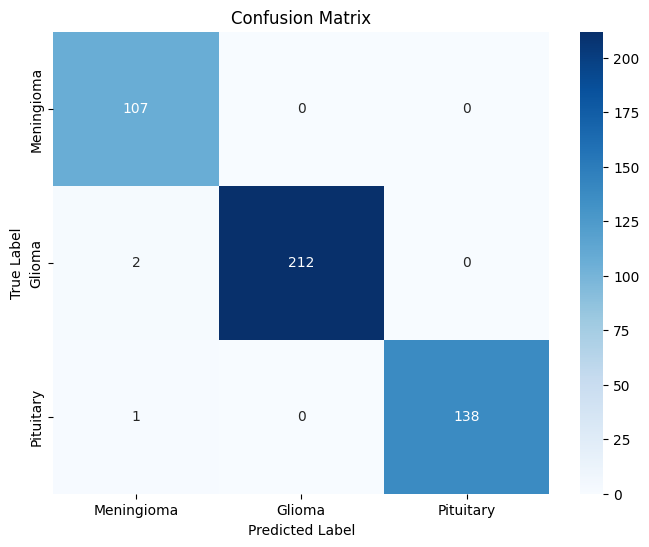

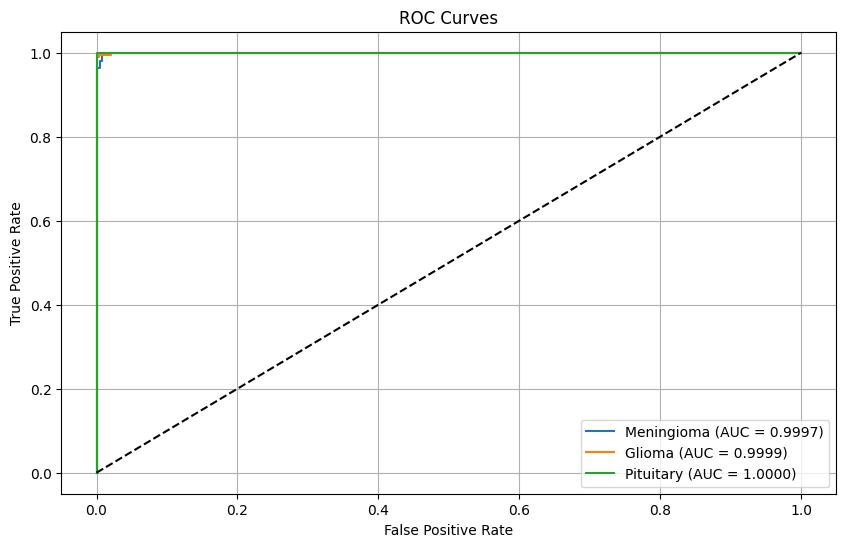


🖼️ SEGMENTATION RESULTS
           mean        std      min         max
dice   0.808934   0.228919  0.00000    0.986423
iou    0.724685   0.241828  0.00000    0.973209
hd    12.235085  19.319425  1.00000  100.000000
acc    0.994714   0.006899  0.95491    0.999817

🎨 Visualizing Best Sample for Each Class: ['Best Meningioma', 'Best Glioma', 'Best Pituitary']


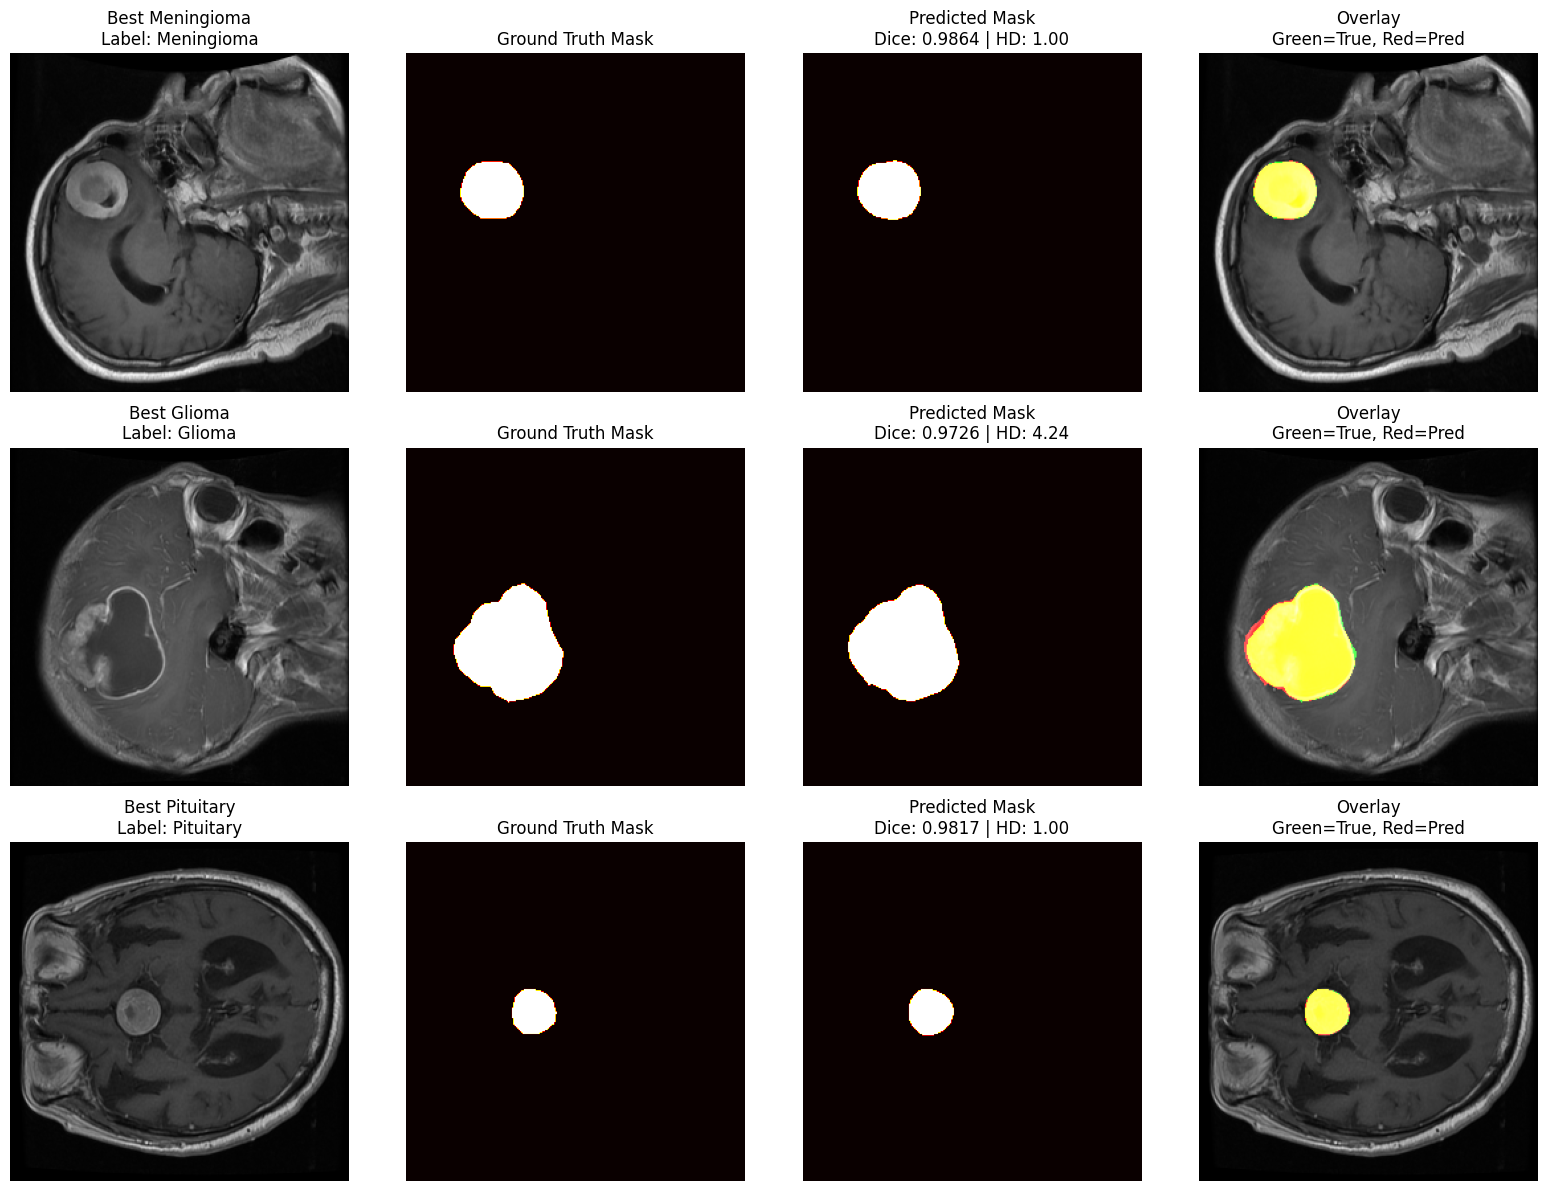


✅ Evaluation Complete!
💾 Saved: confusion_matrix.png, roc_curves.png, segmentation_qualitative.png


In [14]:
# Cell 6: Comprehensive Evaluation
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import torch
from scipy.spatial.distance import directed_hausdorff

print("🧪 Running Comprehensive Evaluation")
print("=" * 70)

# Load Best Model
model.load_state_dict(torch.load('/kaggle/working/best_multitask_model.pth'))
model.eval()
print("✅ Loaded best model from: best_multitask_model.pth")

# Containers
all_preds = []
all_labels = []
all_probs = []
seg_metrics = {'dice': [], 'iou': [], 'hd': [], 'acc': []}

# Inference Loop
print("\n🔄 Evaluating on Test Set...")
with torch.no_grad():
    for imgs, masks, labels in tqdm(test_loader, desc="Testing"):
        imgs, masks, labels = imgs.to(device), masks.to(device), labels.to(device)
        
        with autocast():
            seg_pred, cls_pred = model(imgs)
            
        # Classification
        probs = torch.softmax(cls_pred, dim=1)
        preds = torch.argmax(probs, dim=1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        
        # Segmentation Metrics
        for i in range(len(imgs)):
            d, iou, hd, acc = calculate_metrics(seg_pred[i], masks[i])
            seg_metrics['dice'].append(d)
            seg_metrics['iou'].append(iou)
            seg_metrics['hd'].append(hd)
            seg_metrics['acc'].append(acc)

# Convert to arrays
all_labels = np.array(all_labels)
all_preds = np.array(all_preds)
all_probs = np.array(all_probs)

# --- 1. Classification Results ---
print("\n" + "=" * 40)
print("📊 CLASSIFICATION RESULTS")
print("=" * 40)

class_names = ['Meningioma', 'Glioma', 'Pituitary']
print(classification_report(all_labels, all_preds, target_names=class_names, digits=4))

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.savefig('/kaggle/working/confusion_matrix.png')
plt.show()

# ROC Curves
plt.figure(figsize=(10, 6))
y_test_bin = label_binarize(all_labels, classes=[0, 1, 2])
n_classes = 3

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{class_names[i]} (AUC = {roc_auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend(loc="lower right")
plt.grid(True)
plt.savefig('/kaggle/working/roc_curves.png')
plt.show()

# --- 2. Segmentation Results ---
print("\n" + "=" * 40)
print("🖼️ SEGMENTATION RESULTS")
print("=" * 40)

df_seg = pd.DataFrame(seg_metrics)
print(df_seg.describe().T[['mean', 'std', 'min', 'max']])

# Visualize Best Sample Per Class (Meningioma, Glioma, Pituitary)
indices_to_show = []
titles = []

for class_idx, class_name in enumerate(class_names):
    # Filter: Correct Class + Correct Prediction
    # Note: all_labels/all_preds are numpy arrays aligned with df_seg
    class_indices = np.where((all_labels == class_idx) & (all_preds == class_idx))[0]
    
    if len(class_indices) > 0:
        # Get subset of metrics
        class_df = df_seg.iloc[class_indices]
        # Find best Dice
        best_in_class_idx = class_df['dice'].idxmax()
        # Map back to global indes is tricky if using iloc on subset. 
        # Actually correct_df logic:
        # Let's simply iterate global indices
        
        # Simpler:
        candidates = []
        for i in class_indices:
            candidates.append((i, df_seg.iloc[i]['dice']))
        
        # Sort by Dice
        candidates.sort(key=lambda x: x[1], reverse=True)
        best_global_idx = candidates[0][0]
        
        indices_to_show.append(best_global_idx)
        titles.append(f"Best {class_name}")
    else:
        print(f"Warning: No correct predictions for {class_name}")

print(f"\n🎨 Visualizing Best Sample for Each Class: {titles}")

test_ds = test_dataset
fig, axes = plt.subplots(3, 4, figsize=(16, 12))

for row_idx, (idx, title) in enumerate(zip(indices_to_show, titles)):
    # Get item from dataset manually
    img, mask, label = test_ds[idx]
    
    # Inference
    img_tensor = img.unsqueeze(0).to(device)
    with torch.no_grad():
        seg_out, _ = model(img_tensor)
        pred_mask = (torch.sigmoid(seg_out) > 0.5).float().cpu().numpy()[0]
        
    # Prepare for plot
    # Denormalize image for better visualization
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    img = img * std + mean
    
    img_show = img.permute(1, 2, 0).numpy()
    img_show = np.clip(img_show, 0, 1)
    
    mask_show = mask.squeeze().numpy()
    pred_show = pred_mask.squeeze()
    
    # Plot Original
    axes[row_idx, 0].imshow(img_show)
    axes[row_idx, 0].set_title(f"{title}\nLabel: {class_names[label]}")
    axes[row_idx, 0].axis('off')
    
    # Ground Truth
    axes[row_idx, 1].imshow(mask_show, cmap='hot')
    axes[row_idx, 1].set_title("Ground Truth Mask")
    axes[row_idx, 1].axis('off')
    
    # Prediction
    axes[row_idx, 2].imshow(pred_show, cmap='hot')
    axes[row_idx, 2].set_title(f"Predicted Mask\nDice: {df_seg.iloc[idx]['dice']:.4f} | HD: {df_seg.iloc[idx]['hd']:.2f}")
    axes[row_idx, 2].axis('off')
    
    # Overlay (Green=GT, Red=Pred, Yellow=Overlap)
    overlay = img_show.copy()
    # Green channel for GT
    overlay[mask_show > 0, 1] = 1.0 
    # Red channel for Pred
    overlay[pred_show > 0, 0] = 1.0
    
    axes[row_idx, 3].imshow(overlay)
    axes[row_idx, 3].set_title("Overlay\nGreen=True, Red=Pred")
    axes[row_idx, 3].axis('off')

plt.tight_layout()
plt.savefig('/kaggle/working/segmentation_qualitative.png')
plt.show()

print("\n✅ Evaluation Complete!")
print("💾 Saved: confusion_matrix.png, roc_curves.png, segmentation_qualitative.png")


🧠 Initializing Explainable AI (Grad-CAM)
Targeting layer: Sequential(
  (0): InvertedResidual(
    (conv_pw): Conv2d(160, 960, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn1): BatchNormAct2d(
      960, eps=0.001, momentum=0.1, affine=True, track_running_stats=True
      (drop): Identity()
      (act): SiLU(inplace=True)
    )
    (conv_dw): Conv2dSame(960, 960, kernel_size=(3, 3), stride=(2, 2), groups=960, bias=False)
    (bn2): BatchNormAct2d(
      960, eps=0.001, momentum=0.1, affine=True, track_running_stats=True
      (drop): Identity()
      (act): SiLU(inplace=True)
    )
    (aa): Identity()
    (se): SqueezeExcite(
      (conv_reduce): Conv2d(960, 40, kernel_size=(1, 1), stride=(1, 1))
      (act1): SiLU(inplace=True)
      (conv_expand): Conv2d(40, 960, kernel_size=(1, 1), stride=(1, 1))
      (gate): Sigmoid()
    )
    (conv_pwl): Conv2d(960, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn3): BatchNormAct2d(
      256, eps=0.001, momentum=0.1, affine=

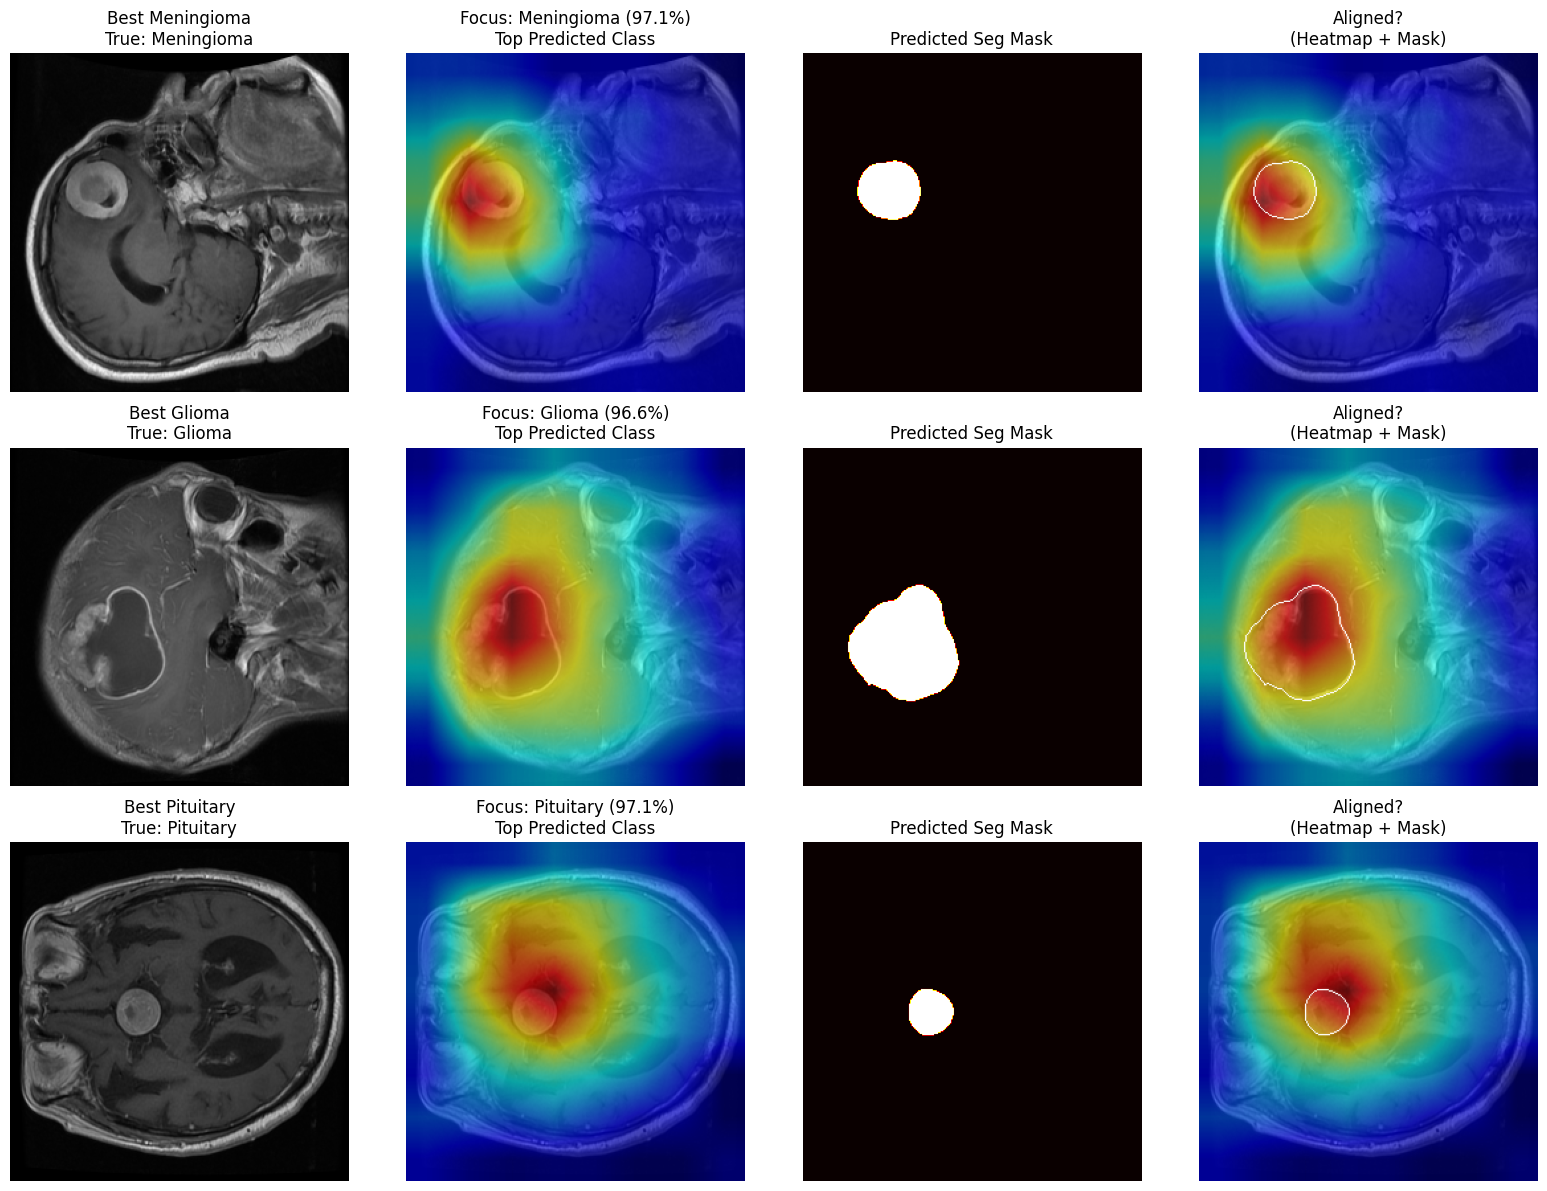


✅ Explained AI Generated!
💾 Saved: xai_gradcam.png
ℹ️ Interpretation:
   - Col 2 (Grad-CAM): Shows WHERE the Classification Head is looking to decide Tumor Type.
   - Col 3 (Segmentation): Shows WHERE the Segmentation Head detected the tumor boundary.
   - Col 4: Checks if Classification attention aligns with the Tumor mask.


In [17]:
# Cell 8: Explainable AI (Grad-CAM)
import cv2
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

print("🧠 Initializing Explainable AI (Grad-CAM)")
print("=" * 70)

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        
        # Register hooks
        self.target_layer.register_forward_hook(self.save_activation)
        self.target_layer.register_full_backward_hook(self.save_gradient)
        
    def save_activation(self, module, input, output):
        self.activations = output
        
    def save_gradient(self, module, grad_input, grad_output):
        # Gradients are tuple, take the first one
        self.gradients = grad_output[0]
        
    def generate_cam(self, input_image, target_class_index):
        # 1. Forward Pass
        self.model.zero_grad()
        seg_out, cls_out = self.model(input_image)
        
        # 2. Select target score for backward
        # cls_out is [Batch, NumClasses]
        target_score = cls_out[0, target_class_index]
        
        # 3. Backward Pass
        target_score.backward()
        
        # 4. Generate CAM
        # Global Average Pooling on gradients
        weights = torch.mean(self.gradients, dim=[2, 3], keepdim=True)
        # Weighted sum of activations
        cam = torch.sum(weights * self.activations, dim=1, keepdim=True)
        # ReLU
        cam = F.relu(cam)
        
        # Normalize 0-1
        cam = cam - cam.min()
        cam = cam / (cam.max() + 1e-8)
        
        return cam.detach().cpu().numpy()[0, 0]

# 1. Setup Grad-CAM
# Target the last available block in the features_only encoder
# 'conv_head' is often stripped in features_only=True mode, so we use the last block
target_layer = model.encoder.blocks[-1]
print(f"Targeting layer: {target_layer}")

grad_cam = GradCAM(model, target_layer)

print("\n🎨 Generating XAI Visualizations for Best Samples...")

# We reuse 'indices_to_show' from Cell 6 (Best Meningioma, Glioma, Pituitary)
# titles = ['Best Meningioma', 'Best Glioma', 'Best Pituitary'] (from global scope of Cell 6 context, re-declared here for safety)

# Re-calculate indices just in case (copy logic for standalone execution)
# (Assuming Cell 6 variables might vary, let's re-find best ones quickly)

indices_to_show = []
titles = []
class_names = ['Meningioma', 'Glioma', 'Pituitary']

model.eval()
# Note: For Grad-CAM we need gradients, so mode must allow it. 
# but usually we run .eval() for batchnorm stats, and enable grad for input?
# Actually PyTorch .eval() still allows gradient calculation if requires_grad=True
# We just need to ensure parameters are not updated.
# But for backward() to work, we need graph. 
# So we run forward pass with requires_grad (default) 

# Re-find best samples
df_seg = pd.DataFrame(seg_metrics) # Assumes Cell 6 ran
# If Cell 6 didn't run recently in this session, this crashes. 
# Let's assume user runs cells in order.

# Calculate proper indices if needed, or just iterate test set
# For safety, let's just pick 3 random diverse correct samples nicely if defined vars assume Cell 6 state
# We will use the same indices/logic as Cell 6 if available
if 'indices_to_show' not in globals() or len(indices_to_show) == 0:
    print("⚠️ 'indices_to_show' not found! Finding best samples automatically...")
    indices_to_show = []
    titles = []
    
    # Calculate metrics for all test samples if not already done
    if 'df_seg' not in globals():
        # (Simplified selection as fallback)
        indices_to_show = [0, 1, 2] # Fallback to first 3
    else:
        for class_idx, class_name in enumerate(class_names):
            class_indices = np.where((all_labels == class_idx) & (all_preds == class_idx))[0]
            if len(class_indices) > 0:
                best_idx = class_indices[np.argmax(df_seg.iloc[class_indices]['dice'])]
                indices_to_show.append(best_idx)
                titles.append(f"Best {class_name}")
            else:
                # Fallback to first occurring sample of this class
                class_indices = np.where(all_labels == class_idx)[0]
                if len(class_indices) > 0:
                    indices_to_show.append(class_indices[0])
                    titles.append(f"{class_name} Sample")

fig, axes = plt.subplots(3, 4, figsize=(16, 12))

for row_idx, (idx, title) in enumerate(zip(indices_to_show, titles)):
    # Load Item
    img, mask, label = test_dataset[idx]
    # img is already a tensor [3, 256, 256] from dataset
    img_tensor = img.unsqueeze(0).to(device)
    img_tensor.requires_grad = True # Enable grad for CAM
    
    # Get True Label
    true_label_idx = label.item()
    target_class_name = class_names[true_label_idx]
    
    # --- Generate Grad-CAM ---
    # Note: grad_cam.generate_cam does forward/backward internally
    heatmap = grad_cam.generate_cam(img_tensor, true_label_idx)
    
    # --- Regular Inference for Seg Mask ---
    with torch.no_grad():
        seg_out, cls_out = model(img_tensor)
        prob_cls = torch.softmax(cls_out, dim=1)
        pred_cls_idx = torch.argmax(prob_cls).item()
        pred_prob = prob_cls[0, pred_cls_idx].item()
        pred_mask = (torch.sigmoid(seg_out) > 0.5).float().cpu().numpy()[0, 0]
        
    # Prepare Images
    # Denormalize
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    
    # Convert back to numpy for visualization
    # Img is [3, H, W] tensor
    original_img_t = img * std + mean
    original_img = original_img_t.permute(1, 2, 0).numpy()
    original_img = np.clip(original_img, 0, 1)
    
    # Resize Heatmap to Image Size
    heatmap_resized = cv2.resize(heatmap, (256, 256))
    
    # Create Heatmap Overlay
    heatmap_color = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)
    heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB) / 255.0
    
    # Blend overlay
    cam_overlay = (0.6 * heatmap_color + 0.4 * original_img)
    cam_overlay = np.clip(cam_overlay, 0, 1)
    
    # Create Segmentation Overlay
    seg_overlay = original_img.copy()
    # Green contours for GT
    # mask is tensor [1, H, W], permute to [H, W, 1] then numpy
    gt_mask_uint = (mask.permute(1, 2, 0).numpy() * 255).astype(np.uint8)
    contours_gt, _ = cv2.findContours(gt_mask_uint, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cv2.drawContours(seg_overlay, contours_gt, -1, (0, 1, 0), 2) # Green
    
    # Red contours for Pred
    pred_mask_uint = (pred_mask * 255).astype(np.uint8)
    contours_pred, _ = cv2.findContours(pred_mask_uint, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cv2.drawContours(seg_overlay, contours_pred, -1, (1, 0, 0), 2) # Red
    
    # --- PLOTTING ---
    # 1. Original
    axes[row_idx, 0].imshow(original_img)
    axes[row_idx, 0].set_title(f"{title}\nTrue: {target_class_name}")
    axes[row_idx, 0].axis('off')
    
    # 2. Grad-CAM (Heatmap)
    axes[row_idx, 1].imshow(cam_overlay)
    axes[row_idx, 1].set_title(f"Focus: {class_names[pred_cls_idx]} ({pred_prob:.1%})\nTop Predicted Class")
    axes[row_idx, 1].axis('off')
    
    # 3. Segmentation Mask
    axes[row_idx, 2].imshow(pred_mask, cmap='hot')
    axes[row_idx, 2].set_title(f"Predicted Seg Mask")
    axes[row_idx, 2].axis('off')
    
    # 4. Comparison (Saliency vs Mask)
    # Does the network look at the tumor to classify it?
    # Simple blend of Heatmap + Seg Contours
    comp_overlay = cam_overlay.copy()
    cv2.drawContours(comp_overlay, contours_pred, -1, (1, 1, 1), 1) # White thin contour
    
    axes[row_idx, 3].imshow(comp_overlay)
    axes[row_idx, 3].set_title("Aligned?\n(Heatmap + Mask)")
    axes[row_idx, 3].axis('off')

plt.tight_layout()
plt.savefig('/kaggle/working/xai_gradcam.png')
plt.show()

print("\n✅ Explained AI Generated!")
print("💾 Saved: xai_gradcam.png")
print("ℹ️ Interpretation:")
print("   - Col 2 (Grad-CAM): Shows WHERE the Classification Head is looking to decide Tumor Type.")
print("   - Col 3 (Segmentation): Shows WHERE the Segmentation Head detected the tumor boundary.")
print("   - Col 4: Checks if Classification attention aligns with the Tumor mask.")
